In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.preprocessing import normalize

In [ ]:
# paths and configs
COSINE_DIR = Path("training_hosts_cosine_similarities")
OUT_DIR = Path("new_strains_assignment_results/15new_strains_assigned_clusters")
FIG_DIR = Path("new_strains_assignment_results/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

MODELS = ["ESM2", "ESMC", "LucaOne", "AF3", "BacFormer"]
Q_LIST = [0.999, 0.995, 0.990, 0.950, 0.900, 0.850, 0.800, 0.750]

In [3]:
# cosine similarity files
COSINE_FILES = {
    model: next(
        p for p in COSINE_DIR.glob("*.csv")
        if model.lower() in p.name.lower()
    )
    for model in MODELS
}

COSINE_FILES

{'ESM2': PosixPath('training_hosts_cosine_similarities/host_cosine_similarity_ESM2_centered_0to1_PhageHost.csv'),
 'ESMC': PosixPath('training_hosts_cosine_similarities/host_cosine_similarity_ESMC_centered_0to1_PhageHost.csv'),
 'LucaOne': PosixPath('training_hosts_cosine_similarities/host_cosine_similarity_LucaOne_centered_0to1_PhageHost.csv'),
 'AF3': PosixPath('training_hosts_cosine_similarities/host_cosine_similarity_AF3_centered_0to1_PhageHost.csv'),
 'BacFormer': PosixPath('training_hosts_cosine_similarities/host_cosine_similarity_Bacformer_centered_0to1_PhageHost.csv')}

In [4]:
# respective model embeddings

EMBEDDING_FILES = {
    "ESM2": {
        "train": Path("training_host_embeddings/host_klocus_esm2_colmean_embeddings.csv"),
        "new": Path("inVitro_data/PH_15strains_embeddings/ESM2/k_loci_ESM2_invitro_15strains_colmean_embeddings.csv"),
    },
    "ESMC": {
        "train": Path("training_host_embeddings/host_klocus_esmc_colmean_embeddings.csv"),
        "new": Path("inVitro_data/PH_15strains_embeddings/ESMC/k_loci_ESMC_invitro_15strains_colmean_embeddings.csv"),
    },
    "LucaOne": {
        "train": Path("training_host_embeddings/host_klocus_lucaone_colmean_embeddings.csv"),
        "new": Path("inVitro_data/PH_15strains_embeddings/LucaOne/k_loci_LucaOne_inVitro_15strains_colmean_embeddings.csv"),
    },
    "AF3": {
        "train": Path("training_host_embeddings/PH_esm_if1_locibase_af3_structural_embeddings_col_mean.csv"),
        "new": Path("inVitro_data/PH_15strains_embeddings/AF3/15strains_esm_if1_locibase_af3_structural_embeddings_col_mean.csv"),
    },
    "BacFormer": {
        "train": Path("training_host_embeddings/Locibase_colWmean_bacformer_embeddings.csv"),
        "new": Path("inVitro_data/PH_15strains_embeddings/BacFormer/Locibase_colWmean_bacformer_embeddings_15strains.csv"),
    },
}

In [ ]:
# loading helper functions
def load_embedding(path):
    df = pd.read_csv(path, index_col=0)
    df.index = (df.index.astype(str).str.strip())
    df = df.apply(pd.to_numeric)
    return df

def load_cosine(path):
    df = pd.read_csv(path, index_col=0)
    df.index = df.index.astype(str).str.strip()
    df.columns = df.columns.astype(str).str.strip()
    return df

In [ ]:
# actual loading of embeddings and cos-similalities

embeddings = {}
training_cosine = {}
for model in MODELS:
    embeddings[model] = {
        "train": load_embedding(EMBEDDING_FILES[model]["train"]),
        "new": load_embedding(EMBEDDING_FILES[model]["new"])
    }

    training_cosine[model] = load_cosine(COSINE_FILES[model])
    print(model, embeddings[model]["train"].shape, embeddings[model]["new"].shape)

ESM2 (121, 1280) (15, 1280)
ESMC (121, 1152) (15, 1152)
LucaOne (121, 2560) (15, 2560)
AF3 (121, 512) (15, 512)
BacFormer (121, 480) (15, 480)


In [ ]:
# computing similarities between new and training data
def new_host_similarity(train_df, new_df):
    X_train = train_df.values.astype(float)
    X_new = new_df.values.astype(float)
    mean = X_train.mean(axis=0)

    X_train = normalize(X_train - mean, norm="l2", axis=1)
    X_new = normalize(X_new - mean, norm="l2", axis=1)

    return (X_new @ X_train.T + 1) / 2

similarities = {}
for model in MODELS:
    similarities[model] = new_host_similarity(embeddings[model]["train"], embeddings[model]["new"])
    print(model, similarities[model].shape)

ESM2 (15, 121)
ESMC (15, 121)
LucaOne (15, 121)
AF3 (15, 121)
BacFormer (15, 121)


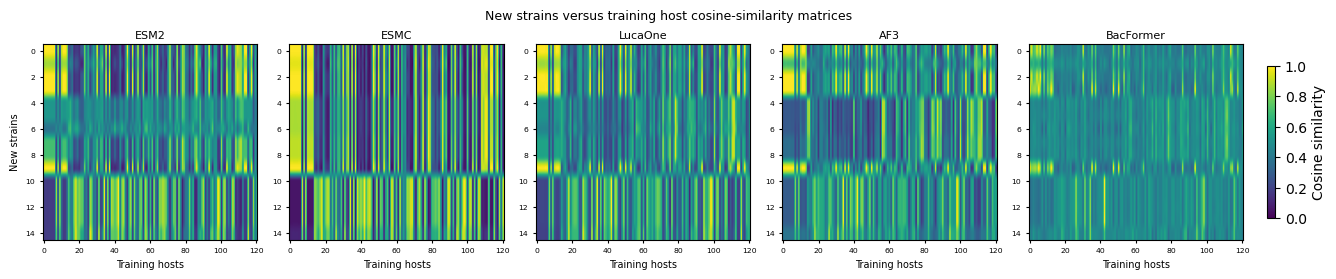

In [ ]:
# Visualizing new strains versus training host cosine similarities

import matplotlib.pyplot as plt

models = list(similarities.keys())
n_models = len(models)

fig, axes = plt.subplots(1, n_models, figsize=(2.65 * n_models, 2.68), squeeze=False, constrained_layout=True)
for j, model in enumerate(models):
    ax = axes[0, j]
    im = ax.imshow(similarities[model], vmin=0, vmax=1, aspect="auto")

    ax.set_title(model, fontsize=8, pad=4)
    ax.set_xlabel("Training hosts", fontsize=7)

    if j == 0:
        ax.set_ylabel("New strains", fontsize=7)
    else:
        ax.set_ylabel("")
    ax.tick_params(axis="both", labelsize=5.5, length=2)

fig.colorbar(im, ax=axes, label="Cosine similarity", shrink=0.78, pad=0.015)
fig.suptitle("New strains versus training host cosine-similarity matrices", fontsize=9)

fig.savefig(FIG_DIR / "new_vs_training_host_cosine_similarity_matrices.png", dpi=500, bbox_inches="tight")
plt.show()

In [9]:
# calculating the training quantile thresholds
thresholds = {}
for model in MODELS:
    M = training_cosine[model].values
    off_diag = M[
        ~np.eye(
            M.shape[0],
            dtype=bool
        )
    ]
    thresholds[model] = {
        q: np.quantile(off_diag, q)
        for q in Q_LIST
    }

In [10]:
# Assign highest supported quantile

assignments = []
for model in MODELS:
    S = similarities[model]
    new_hosts = embeddings[model]["new"].index
    for i, host in enumerate(new_hosts):
        max_supported = None
        max_similarity = S[i].max()
        for q in Q_LIST:
            if max_similarity >= thresholds[model][q]:
                max_supported = q
                break

        assignments.append(
            {
                "model": model,
                "host_id": host,
                "max_similarity": max_similarity,
                "quantile": max_supported,
                "support_status": (
                    "supported"
                    if max_supported is not None
                    else "no_support"
                ),
            }
        )

assignment_df = pd.DataFrame(assignments)
display(assignment_df)

,model,host_id,max_similarity,quantile,support_status
0,ESM2,IM001,0.999909,0.995,supported
1,ESM2,IM018,0.906610,0.900,supported
2,ESM2,IM043,0.999989,0.999,supported
3,ESM2,IM061_1,0.999976,0.999,supported
4,ESM2,IM066,0.720130,NaN,no_support
...,...,...,...,...,...
70,BacFormer,NK06130,1.000000,0.999,supported
71,BacFormer,NK06145,1.000000,0.999,supported
72,BacFormer,NK06248,0.982610,0.990,supported
73,BacFormer,NK08119,1.000000,0.999,supported


In [ ]:
# Assign lowest quantile only to hosts unsupported by all models

LOWEST_Q = min(Q_LIST)
host_support = (
    assignment_df
    .groupby("host_id")["support_status"]
    .apply(lambda x: x.eq("supported").any())
    .rename("supported_by_any_model")
    .reset_index()
)

fallback_hosts = host_support.loc[~host_support["supported_by_any_model"], "host_id"].tolist()
print("Hosts unsupported by all models:", len(fallback_hosts))
if fallback_hosts:
    display(pd.DataFrame({"host_id": fallback_hosts}))

assignment_df = assignment_df.merge(
    host_support,
    on="host_id",
    how="left",
    validate="many_to_one",
)

fallback_mask = (~assignment_df["supported_by_any_model"] & assignment_df["support_status"].eq("no_support"))

assignment_df.loc[fallback_mask, "quantile"] = LOWEST_Q
assignment_df.loc[fallback_mask, "support_status"] = "fallback_lowest_quantile"
assignment_df = assignment_df.drop(columns="supported_by_any_model")

display(assignment_df.groupby("support_status").size().reset_index(name="n_assignments"))

Hosts unsupported by all models: 0


,support_status,n_assignments
0,no_support,1
1,supported,74


In [12]:
# Saving the assignment table
OUT_FILE = (OUT_DIR / "15new_strains_highest_supported_quantile_by_model_NEW.csv")
assignment_df.to_csv(OUT_FILE, index=False)
print("Saved:", OUT_FILE)

Saved: new_strains_assignment_results/15new_strains_assigned_clusters/15new_strains_highest_supported_quantile_by_model_NEW.csv


In [ ]:
# Summary
print(f"Total model assignments: {len(assignment_df)}")
display(assignment_df.groupby(["model", "quantile", "support_status"], dropna=False).size().reset_index(name="n_hosts"))

Total model assignments: 75


,model,quantile,support_status,n_hosts
0,AF3,0.900,supported,7
1,AF3,0.995,supported,8
2,BacFormer,0.850,supported,1
3,BacFormer,0.900,supported,3
4,BacFormer,0.950,supported,3
5,BacFormer,0.990,supported,3
6,BacFormer,0.995,supported,2
7,BacFormer,0.999,supported,3
8,ESM2,0.750,supported,2
9,ESM2,0.900,supported,3


In [14]:
# Checking that every new host is covered by at least one model

host_coverage = (
    assignment_df
    .assign(usable=assignment_df["support_status"].isin(["supported", "fallback_lowest_quantile"]))
    .groupby("host_id")["usable"]
    .any()
)
uncovered_hosts = host_coverage[~host_coverage].index.tolist()

print("Total new hosts:", assignment_df["host_id"].nunique())
print("Hosts unsupported by all models after fallback:", len(uncovered_hosts))
if uncovered_hosts:
    display(pd.DataFrame({"host_id": uncovered_hosts}))
    raise ValueError("Some hosts remain unsupported by all models.")

Total new hosts: 15
Hosts unsupported by all models after fallback: 0


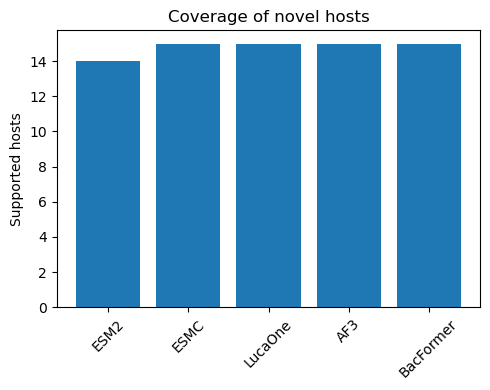

In [ ]:
# Host-unseen supported host coverage summary
host_summary = (
    assignment_df[assignment_df["support_status"].eq("supported")]
    .groupby("model")
    .size()
    .reindex(MODELS, fill_value=0)
    .rename("supported_hosts")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(host_summary["model"], host_summary["supported_hosts"])

ax.set_title("Coverage of novel hosts")
ax.set_ylabel("Supported hosts")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "host_unseen_assignment_summary.png", dpi=500, bbox_inches="tight")
plt.show()